# Classification algorithms

### Dataset description, visualisation, and pre-processing

<div class="alert alert-block alert-warning">The Heart Disease Detection dataset is composed of a set of characteristics used to determine if a patient has heart disease or not. Its main purpose is to perform classification based on the target variable, 'HeartDisease,' which indicates the presence of heart disease in the patient. This variable has integer values where 0 represents no disease and 1 indicates the presence of disease.
<div/>

<div class="alert alert-block alert-danger"> 
    
1. Import the Heart Disease Detection dataset.
2. Display and try to understand each feature in this dataset.
3. Display a summary of the dataset.
4. Verify if the dataset contains any missing values.
5. Plot the distribution of samples according to the target variable HeartDisease. Determine if the dataset is balanced.
6. Apply dummy encoding to all categorical features in the dataset.
7. Display the Pearson correlation matrix. Is there a correlation with the class and between features by considering a thresholed of 0.5?
8. Display the distribution of all features on all the scaled data (except binary features) using a histplot. What do you observe?
9. Split the data into a training and a testing set using a ratio of 0.3.
10. Normalize the data using z-score scaling.
<div/>

display ds :
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

summary of the dataset:
               Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.3965

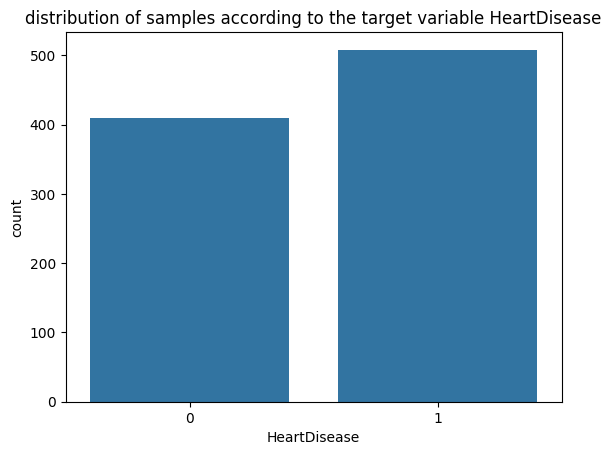

Class Distribution:
 HeartDisease
1    508
0    410
Name: count, dtype: int64

Class Proportions:
 HeartDisease
1    0.553377
0    0.446623
Name: count, dtype: float64
The dataset is imbalanced.

encoded ds
    Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172        0             0   
1   49        160          180          0    156        1             1   
2   37        130          283          0     98        0             0   
3   48        138          214          0    108        1             1   
4   54        150          195          0    122        0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0      1                  1                  0                 0   
1      0                  0                  1                 0   
2      1                  1                  0                 0   
3      0                  0                  0                 0   
4

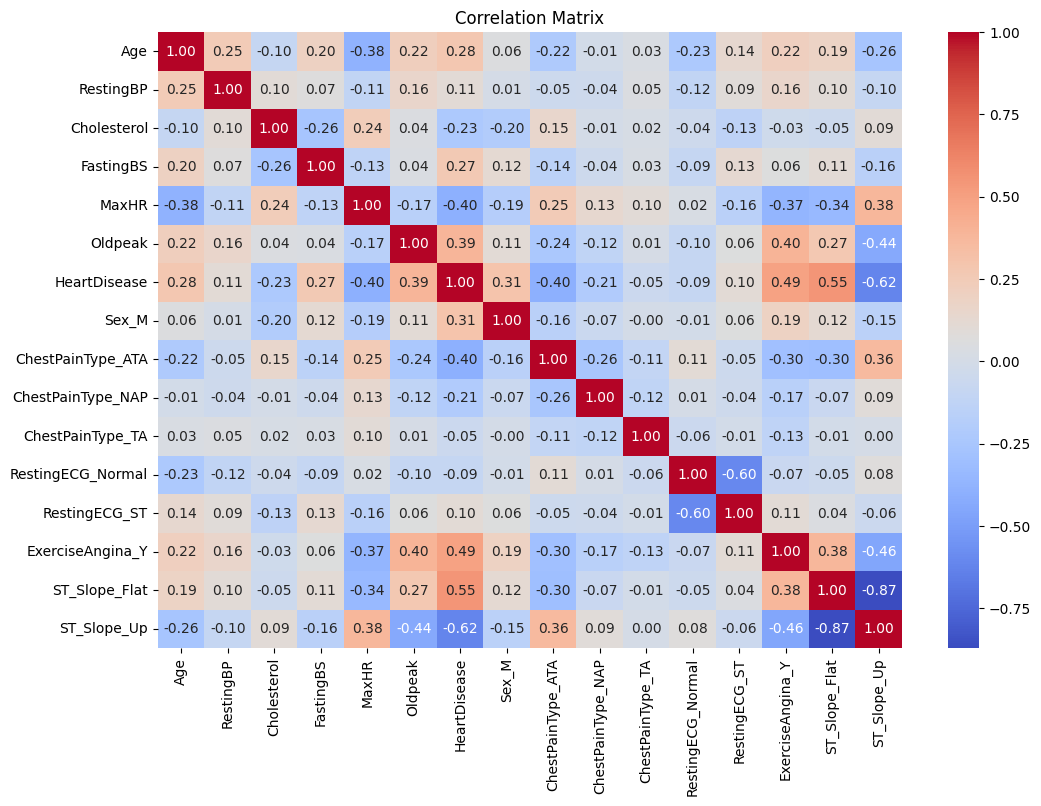


features Correlated with HeartDisease:
 HeartDisease     1.000000
ST_Slope_Flat    0.554134
ST_Slope_Up     -0.622164
Name: HeartDisease, dtype: float64


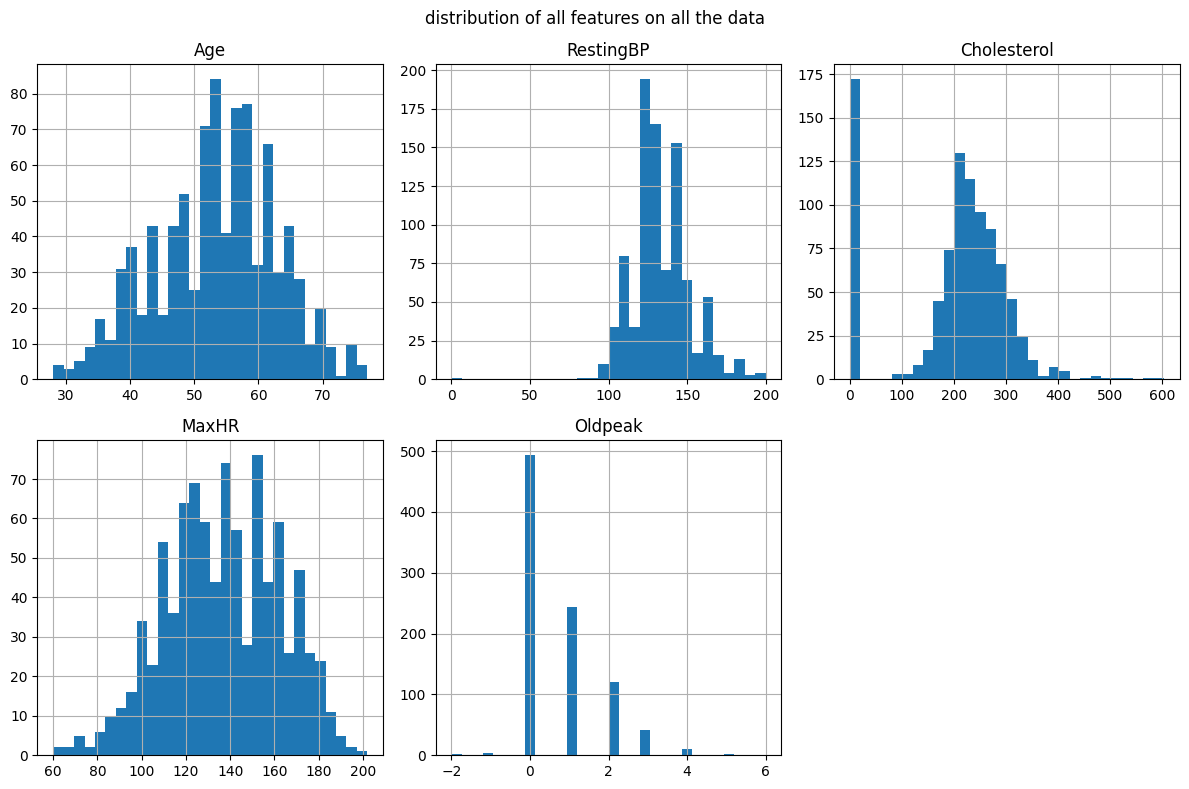


Training Set Size: (642, 15)
Testing Set Size: (276, 15)

Data normalized and ready for modeling!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#1Import the Heart Disease Detection dataset.
data = pd.read_csv('heart.csv')

#2 Display and try to understand each feature in this dataset.
print("display ds :\n", data.head())

#3 Display a summary of the dataset.

print("\nsummary of the dataset:\n", data.describe())

#4 Verify if the dataset contains any missing values.

print("\nany missing values:\n",  data.isnull().sum())

#5 Plot the distribution of samples according to the target variable HeartDisease.
# Determine if the dataset is balanced.
sns.countplot(x='HeartDisease', data=data)
plt.title('distribution(samples,HeartDisease)')
plt.show()


class_distribution = data['HeartDisease'].value_counts()
print("Class Distribution:\n", class_distribution)

class_proportions = class_distribution / len(data)
print("\nClass Proportions:\n", class_proportions)

if abs(class_proportions[1] - class_proportions[0]) <= 0.1:
    print("The dataset is moderately balanced.")
else:
    print("The dataset is imbalanced.")


#6Apply dummy encoding to all categorical features in the dataset.


#dummy encoding => convert categorical variables into numerical form
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
#Converts these categorical columns into multiple binary (0/1) columns
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)
data_encoded = data_encoded.astype(int)
print("\nencoded ds\n", data_encoded.head())

#7 Display the Pearson correlation matrix. 
# Is there a correlation with the class and between features by considering a thresholed of 0.5?
matricecorr = data_encoded.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(matricecorr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

corrM = matricecorr['HeartDisease']
corrfeat = corrM[corrM.abs() > 0.5]
print("\nfeatures Correlated with HeartDisease:\n", corrfeat)

numfeat = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
numdata = data_encoded[numfeat]

# Scaling the features =>
# normaliser les données. Il met chaque feature à la même échelle en 
# Retirant la moyenne de chaque feature.
# Divisant par l'écart type

# scaler = StandardScaler()
# scaled_data = pd.DataFrame(scaler.fit_transform(numdata), columns=numfeat)


#8 Display the distribution of all features on all the scaled data (except binary features) using a histplot.
#  What do you observe?
numdata.hist(bins=30, figsize=(12, 8), layout=(2, 3))
plt.suptitle('distribution of all features on all the data')
plt.tight_layout()
plt.show()

#9 Split the data into a training and a testing set using a ratio of 0.3.
X = data_encoded.drop(columns=['HeartDisease'])
y = data_encoded['HeartDisease']
# 70% d'entraînement
# 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nsize of training set", X_train.shape)
print("size of testing set:", X_test.shape)

#10 Normalize the data using z-score scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #Applique la normalisation

print("\nData normalized and ready for modeling!")
